## Seepage vs Δh Model Comparison


This notebook compares two models for seepage as a function of the water-level difference 
between estuary and ocean Δh, using an effective berm conductance $K$.

We model seepage as:

$$
S \;=\; K(\Delta h)\,\Delta h,
$$
where $(K(\Delta h))$ is an *effective berm conductance*. We compare two alternative models for $(K(\Delta h))$:

- **Constant $(K)$ (linear fit):**
$$
K(\Delta h) \;=\; K 
\quad\Rightarrow\quad
S \;=\; K \cdot \Delta h
$$

- **Offset–power $(K)$ :**
$$
K(\Delta h) \;=\; K \cdot(\Delta h+\text{offset})^{b}
\quad\Rightarrow\quad
S \;=\; K \cdot (\Delta h+\text{offset})^{b} \cdot \Delta h
$$

Here, offset represents an effective $\Delta h$ threshold for flow.


### Model-comparison approaches
1. *Pooled fit*: one parameter set fit to all closure events.  
2. *Per-event fits:* parameters estimated separately within each event; results summarized across events.

### Evaluation
- *Information criteria:* *sum* event-level AIC/BIC for per-event fits (equivalently, sum $(-2\log L$) and add penalties).  
- *Goodness of fit:* report R^2 and RMSE; provide unweighted and duration-weighted summaries across events.


Preliminary 
seepage really strong,
two models
linear model.
based on idea the flow path cross section area doesn't change much with water level
following same pipe eachn time 
depends linearly on h
convenient for management purposes

other model - quadratic, homogeneous sand barrier, gravel, flow cross sectional area should increase with rising water level, dependence close to quadratic, w value flow length doesn't change much with water level
how deep the flow path, whether to compare estuary to mean sea level / mean low tide level.
doesn't seem to matter all that much, general model.

 

In [21]:
# ==============================================
# Seepage vs Δh / visitor_h
# Global bounds + Global x_ref + n-weighted grouped medians
# SSE loss
# ==============================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# -----------------------------
# Config
# -----------------------------
data_path = Path("../data/processed/pooled_event_df.csv")   # <- change if needed
eps = 1e-5
min_n_per_event = 5                       # min days to include an event in grouped fits

# Gentle, site-scale caps for positive offsets (upper bounds)
site_cap_dh  = 1.0   # for Δh-based model
site_cap_vis = 1.0   # for visitor_h-based model

# -----------------------------
# Data loading / preparation
# -----------------------------
df = pd.read_csv(data_path)
df["delta_h"] = pd.to_numeric(df.get("delta_h"), errors="coerce")
df["seepage"] = pd.to_numeric(df.get("seepage"), errors="coerce")
df["visitor_h"] = pd.to_numeric(df.get("visitor_h"), errors="coerce")

# minimal clean
df = df.dropna(subset=["delta_h", "seepage", "visitor_h"]).copy()
df['ratio'] = df['seepage']/df['delta_h']
df = df.query("ratio < 2.1")

# per-event row counts
df["n"] = df.groupby("event")["event"].transform("size").astype("int64")

print(f"Rows: {len(df):,} | Events: {df['event'].nunique():,}")

# -----------------------------
# Global x_ref per predictor
# -----------------------------
delta_h_ref  = float(np.nanmedian(df["delta_h"].values))
visitor_h_ref = float(np.nanmedian(df["visitor_h"].values)) 

# -----------------------------
# Global offset bounds (per predictor)
# -----------------------------
def compute_global_offset_bounds(x_series: pd.Series, site_cap: float):
    """
    Lower bound ensures (x + offset) >= ~0 everywhere;
    Upper bound is a gentle, site-scale cap informed by spread.
    """
    x = x_series.to_numpy(float)
    if not np.isfinite(x).any():
        return 0.0, site_cap
    lb = - float(np.nanmin(x)) + 1e-9  # keep base >= 0
    q05, q95 = np.nanquantile(x, [0.05, 0.95])
    spread = float(max(q95 - q05, 1e-6))
    ub = min(0.30 * spread, site_cap)
    
    return float(lb), float(ub)

offset_lb_dh,  offset_up_dh  = compute_global_offset_bounds(df["delta_h"], 
                                                            site_cap_dh)
offset_lb_vis, offset_ub_vis = compute_global_offset_bounds(df["visitor_h"], 
                                                            site_cap_vis)


print(f"Global x_ref (Δh)       = {delta_h_ref:.4f}")
print(f"Global x_ref (visitor_h) = {visitor_h_ref:.4f}" if np.isfinite(visitor_h_ref) else "Global x_ref (visitor_h) = N/A")
print(f"Δh  offset bounds:  [{offset_lb_dh:.4f}, {offset_up_dh:.4f}]")
print(f"vis offset bounds:  [{offset_lb_vis:.4f}, {offset_ub_vis:.4f}]" )

# -----------------------------
# Helpers
# -----------------------------
def r2_centered(y, yhat):
    y = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    sst = np.sum((y - np.mean(y))**2)
    if sst <= 0:
        return np.nan
    sse = np.sum((y - yhat)**2)
    return 1.0 - sse / sst

def weighted_median(values, weights):
    """n-weighted median (by event-size) across events."""
    v = np.asarray(values, float)
    w = np.asarray(weights, float)
    ok = np.isfinite(v) & np.isfinite(w) & (w > 0)
    v, w = v[ok], w[ok]
    if len(v) == 0:
        return np.nan
    order = np.argsort(v)
    v, w = v[order], w[order]
    cw = np.cumsum(w) / np.sum(w)
    return float(v[np.searchsorted(cw, 0.5)])


# Models
def model_linear(K, x):
    return K * x

def model_offset_power_delta_h(K, offset, b, x_dh, delta_h_ref):
    base = np.maximum(x_dh + offset, eps)
    xref = max(delta_h_ref + offset, eps)
    return K * x_dh * np.power(base / xref, b)

def model_offset_power_visitor_h(K, offset, b, x_dh, x_vis, visitor_h_ref):
    base = np.maximum(x_vis + offset, eps)
    xref = max(visitor_h_ref + offset, eps)
    return K * x_dh * np.power(base / xref, b)

# SSE objectives 
def sse_offset_power_delta_h(theta, x_dh, y, delta_h_ref, lb, ub):
    K, off, b = theta
    if (K <= 0) or (b < 0) or (off < lb) or (off > ub):
        return 1e99
    yhat = model_offset_power_delta_h(K, off, b, x_dh, delta_h_ref)
    resid = y - yhat
    return float(np.sum(resid * resid))

def sse_offset_power_visitor_h(theta, x_dh, x_vis, y, visitor_h_ref, lb, ub):
    K, off, b = theta
    if (K <= 0) or (b < 0) or (off < lb) or (off > ub):
        return 1e99
    yhat = model_offset_power_visitor_h(K, off, b, x_dh, x_vis, visitor_h_ref)
    resid = y - yhat
    return float(np.sum(resid * resid))

# -----------------------------
# Pooled fits (SSE)
# -----------------------------
def pooled_linear_delta_h(df_in):
    """
    """
    x = df_in["delta_h"].to_numpy(float)
    y = df_in["seepage"].to_numpy(float)
    # Closed-form through-origin OLS
    denom = max(np.dot(x, x), eps)
    K = float(np.dot(x, y) / denom)
    K = max(K, 1e-12)
    yhat = model_linear(K, x)
    
    return {"K": K, "R2": r2_centered(y, yhat), "n": len(x)}

def pooled_offset_power_delta_h(df_in):
    """
    """
    x = df_in["delta_h"].to_numpy(float)
    y = df_in["seepage"].to_numpy(float)
    K0 = float(np.dot(x, y) / max(np.dot(x, x), eps))
    off0 = (offset_lb_dh + offset_up_dh) / 2.0
    b0 = 0.5
    res = minimize(
        sse_offset_power_delta_h,
        x0=[max(K0, 1e-12), off0, b0],
        args=(x, y, delta_h_ref, offset_lb_dh, offset_up_dh),
        bounds=[(1e-12, None), (offset_lb_dh, offset_up_dh), (1e-12, None)],
        method="L-BFGS-B",
    )
    K, off, b = map(float, res.x)
    yhat = model_offset_power_delta_h(K, off, b, x, delta_h_ref)
    
    return {"K": K, "offset": off, "b": b, "R2": r2_centered(y, yhat), "n": len(x)}

def pooled_offset_power_visitor_h(df_in):
    """
    """
    if not df_in["visitor_h"].notna().any():
        return {}
    sub = df_in.dropna(subset=["visitor_h"]).copy()
    x = sub["delta_h"].to_numpy(float)
    xv = sub["visitor_h"].to_numpy(float)
    y = sub["seepage"].to_numpy(float)
    K0 = float(np.dot(x, y) / max(np.dot(x, x), eps))
    off0 = (offset_lb_vis + offset_ub_vis) / 2.0
    b0 = 0.5
    res = minimize(
        sse_offset_power_visitor_h,
        x0=[max(K0, 1e-12), off0, b0],
        args=(x, xv, y, visitor_h_ref, offset_lb_vis, offset_ub_vis),
        bounds=[(1e-12, None), (offset_lb_vis, offset_ub_vis), (1e-12, None)],
        method="L-BFGS-B",
    )
    K, off, b = map(float, res.x)
    yhat = model_offset_power_visitor_h(K, off, b, x, xv, visitor_h_ref)
    return {"K": K, "offset": off, "b": b, "R2": r2_centered(y, yhat), "n": len(x)}

pooled_lin = pooled_linear_delta_h(df)
pooled_dh  = pooled_offset_power_delta_h(df)
pooled_vis = pooled_offset_power_visitor_h(df)

print("\n=== Pooled (global bounds, global x_ref) ===")
print(f"Linear (Δh):                 K={pooled_lin['K']:.2f},   R²={pooled_lin['R2']:.2f}, n={pooled_lin['n']}")
print(f"Offset–Power (Δh):           K={pooled_dh['K']:.2f}, off={pooled_dh['offset']:.2f}, b={pooled_dh['b']:.2f}, R²={pooled_dh['R2']:.2f}, n={pooled_dh['n']}")

print(f"Offset–Power (visitor_h):    K={pooled_vis['K']:.2f}, off={pooled_vis['offset']:.2f}, b={pooled_vis['b']:.2f}, R²={pooled_vis['R2']:.2f}, n={pooled_vis['n']}")

offset_lb_dh = pooled_dh['offset'] - 0.25
offset_up_dh = pooled_dh['offset'] + 0.25
        
offset_lb_vis = pooled_vis['offset'] - 0.25
offset_ub_vis = pooled_vis['offset'] + 0.25

print ("offset_lb_vis", offset_lb_vis)


# -----------------------------
# Grouped per-event fits (SSE)
# -----------------------------
def fit_grouped_sse(df_in, min_n = min_n_per_event):
    
    rows_lin = []
    rows_dh  = []
    rows_vis = []

    # Pre-check for visitor_h availability
    vis_available = df_in["visitor_h"].notna().any()

    for ev, g in df_in.groupby("event"):
        n = int(len(g))
        if n < min_n:
            continue

        x = g["delta_h"].to_numpy(float)
        y = g["seepage"].to_numpy(float)

        # Linear (Δh) — closed form
        K_lin = float(np.dot(x, y) / max(np.dot(x, x), eps))
        K_lin = max(K_lin, 1e-12)
        yhat_l = model_linear(K_lin, x)
        rows_lin.append({"event": ev, "n": n, "K_lin": K_lin, "R2_lin": r2_centered(y, yhat_l)})


        # Offset–Power (Δh)
        K0 = K_lin
        off0 = (offset_lb_dh + offset_up_dh) / 2.0
        b0 = 0.5
        res_dh = minimize(
            sse_offset_power_delta_h,
            x0=[K0, off0, b0],
            args=(x, y, delta_h_ref, offset_lb_dh, offset_up_dh),
            bounds=[(1e-12, None), (offset_lb_dh, offset_up_dh), (1e-12, None)],
        )
        Kp, offp, bp = map(float, res_dh.x)
        yhat_p = model_offset_power_delta_h(Kp, offp, bp, x, delta_h_ref)
        rows_dh.append({"event": ev, "n": n, "K": Kp, "offset": offp, "b": bp, 
                        "R2": r2_centered(y, yhat_p)})

        # Offset–Power (visitor_h)
        xv = g["visitor_h"].to_numpy(float)
        if np.isfinite(xv).sum() >= min_n:
            K0v = K_lin
            off0v = (offset_lb_vis + offset_ub_vis) / 2.0
            b0v = 0.5
            res_v = minimize(
                sse_offset_power_visitor_h,
                x0=[K0v, off0v, b0v],
                args=(x, xv, y, visitor_h_ref, offset_lb_vis, offset_ub_vis),
                bounds=[(1e-12, None), (offset_lb_vis, offset_ub_vis), (1e-12, None)],
            )

            Kv, offv, bv = map(float, res_v.x)
            yhat_v = model_offset_power_visitor_h(Kv, offv, bv, x, xv, visitor_h_ref)
            rows_vis.append({"event": ev, "n": n, "K": Kv, "offset": offv, "b": bv, 
                             "R2": r2_centered(y, yhat_v)})

    ev_lin = pd.DataFrame(rows_lin).sort_values("event").reset_index(drop=True)
    ev_dh  = pd.DataFrame(rows_dh).sort_values("event").reset_index(drop=True)
    ev_vis = pd.DataFrame(rows_vis).sort_values("event").reset_index(drop=True) if \
                rows_vis else pd.DataFrame()
    return ev_lin, ev_dh, ev_vis

ev_lin, ev_dh, ev_vis = fit_grouped_sse(df, min_n=min_n_per_event)

# -----------------------------
# n-weighted medians of grouped fits
# -----------------------------
def summarize_grouped_weighted_medians(ev_lin, ev_dh, ev_vis):
    out = {}

    if not ev_lin.empty:
        out["Linear (Δh)"] = {
            "K": weighted_median(ev_lin["K_lin"].values, ev_lin["n"].values)
        }

    if not ev_dh.empty:
        out["Offset–Power (Δh)"] = {
            "K":       weighted_median(ev_dh["K"].values, ev_dh["n"].values),
            "offset":  weighted_median(ev_dh["offset"].values, ev_dh["n"].values),
            "b":       weighted_median(ev_dh["b"].values, ev_dh["n"].values),
        }

    if not ev_vis.empty:
        out["Offset–Power (visitor_h)"] = {
            "K":       weighted_median(ev_vis["K"].values, ev_vis["n"].values),
            "offset":  weighted_median(ev_vis["offset"].values, ev_vis["n"].values),
            "b":       weighted_median(ev_vis["b"].values, ev_vis["n"].values),
        }

    return out

wmed = summarize_grouped_weighted_medians(ev_lin, ev_dh, ev_vis)

# -----------------------------
# Comparison table (pooled vs grouped w-med)
# -----------------------------
rows = []

# Linear (Δh)
rows.append({
    "Model": "Linear (Δh)",
    "Pooled K": pooled_lin["K"],
    "Grouped K": wmed.get("Linear (Δh)", {}).get("K", np.nan),
})

# Offset–Power (Δh)
rows.append({
    "Model": "Offset–Power (Δh)",
    "Pooled K":      pooled_dh["K"],
    "Grouped K":      wmed.get("Offset–Power (Δh)", {}).get("K", np.nan),
    "Pooled offset": pooled_dh["offset"],
    "Grouped offset": wmed.get("Offset–Power (Δh)", {}).get("offset", np.nan),
    "Pooled b":      pooled_dh["b"],
    "Grouped b":      wmed.get("Offset–Power (Δh)", {}).get("b", np.nan),
})

# Offset–Power (visitor_h)
rows.append({
    "Model": "Offset–Power (visitor_h)",
    "Pooled K":      pooled_vis["K"],
    "Grouped K":      wmed.get("Offset–Power (visitor_h)", {}).get("K", np.nan),
    "Pooled offset": pooled_vis["offset"],
    "Grouped offset": wmed.get("Offset–Power (visitor_h)", {}).get("offset", np.nan),
    "Pooled b":      pooled_vis["b"],
    "Grouped b":      wmed.get("Offset–Power (visitor_h)", {}).get("b", np.nan),
})

comp = pd.DataFrame(rows)
num_cols = comp.select_dtypes(include=[float, int]).columns
comp[num_cols] = comp[num_cols].round(3)
comp[num_cols] = comp[num_cols].mask(np.isclose(comp[num_cols], 0.0, atol=5e-4), 0.0)

print("\n=== Comparison (Pooled vs Grouped n-weighted medians) ===")
# print(comp.to_string(index=False))
comp

Rows: 430 | Events: 36
Global x_ref (Δh)       = 1.6657
Global x_ref (visitor_h) = 2.6679
Δh  offset bounds:  [-0.6334, 0.4184]
vis offset bounds:  [-1.5992, 0.4086]

=== Pooled (global bounds, global x_ref) ===
Linear (Δh):                 K=1.05,   R²=0.47, n=430
Offset–Power (Δh):           K=1.02, off=0.42, b=0.44, R²=0.50, n=430
Offset–Power (visitor_h):    K=1.02, off=-1.60, b=0.25, R²=0.51, n=430
offset_lb_vis -1.8485782381682576

=== Comparison (Pooled vs Grouped n-weighted medians) ===


,Model,Pooled K,Grouped K,Pooled offset,Grouped offset,Pooled b,Grouped b
0,Linear (Δh),1.051,1.014,NaN,NaN,NaN,NaN
1,Offset–Power (Δh),1.017,0.931,0.418,0.562,0.437,0.413
2,Offset–Power (visitor_h),1.022,0.932,-1.599,-1.433,0.246,0.239


In [22]:

%matplotlib inline

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

plt.rcParams['figure.figsize'] = (12.0, 6.0)


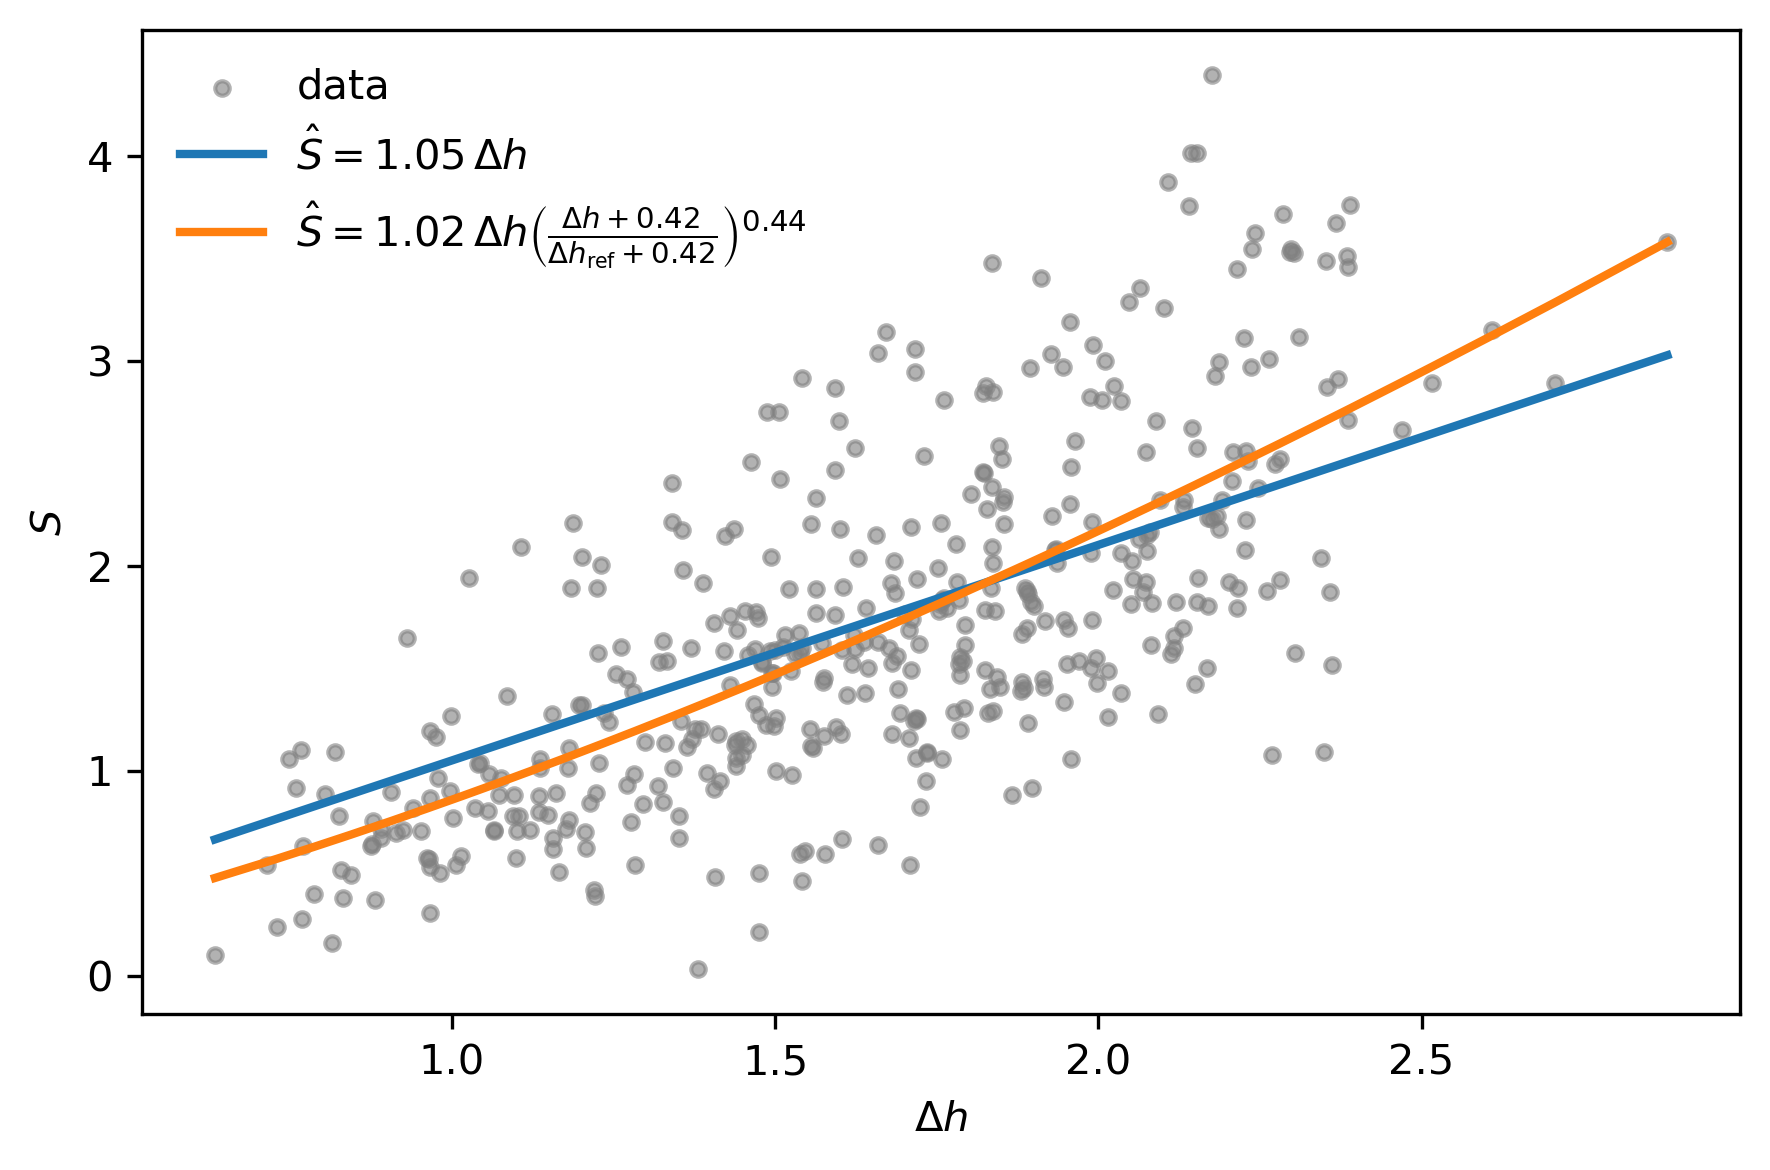

In [62]:
import numpy as np
import matplotlib.pyplot as plt

x_all = df["delta_h"].to_numpy(float)
y_all = df["seepage"].to_numpy(float)

K_lin  = float(pooled_lin["K"])
K_pow  = float(pooled_dh["K"])
off    = float(pooled_dh["offset"])
b      = float(pooled_dh["b"])

order = np.arange(len(x_all))
order = np.argsort(x_all)
xs    = x_all[order]

ys_lin = model_linear(K_lin, xs)
ys_pow = model_offset_power_delta_h(K_pow, off, b, xs, delta_h_ref)

Ktxt   = f"{K_pow:.2f}"
offtxt = f"{off_pow:.2f}"
btxt   = f"{b_pow:.2f}"

label_lin = rf"$\hat S = {K_lin:.2f}\,\Delta h$"
# If your model uses ((Δh+off)/(Δh_ref+off))^b:
label_pow = (
    rf"$\hat S = {Ktxt}\,\Delta h"
    r"\left(\frac{\Delta h+" + offtxt + r"}{\Delta h_{\rm ref}+" + offtxt + r"}\right)^{"
    + btxt + r"}$"
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x_all, y_all, s=12, c="0.5", alpha=0.6, label="data")
ax.plot(xs, ys_lin, lw=2, label=label_lin)
ax.plot(xs, ys_pow, lw=2, label=label_pow)
ax.set_xlabel(r"$\Delta h$")
ax.set_ylabel(r"$S$")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


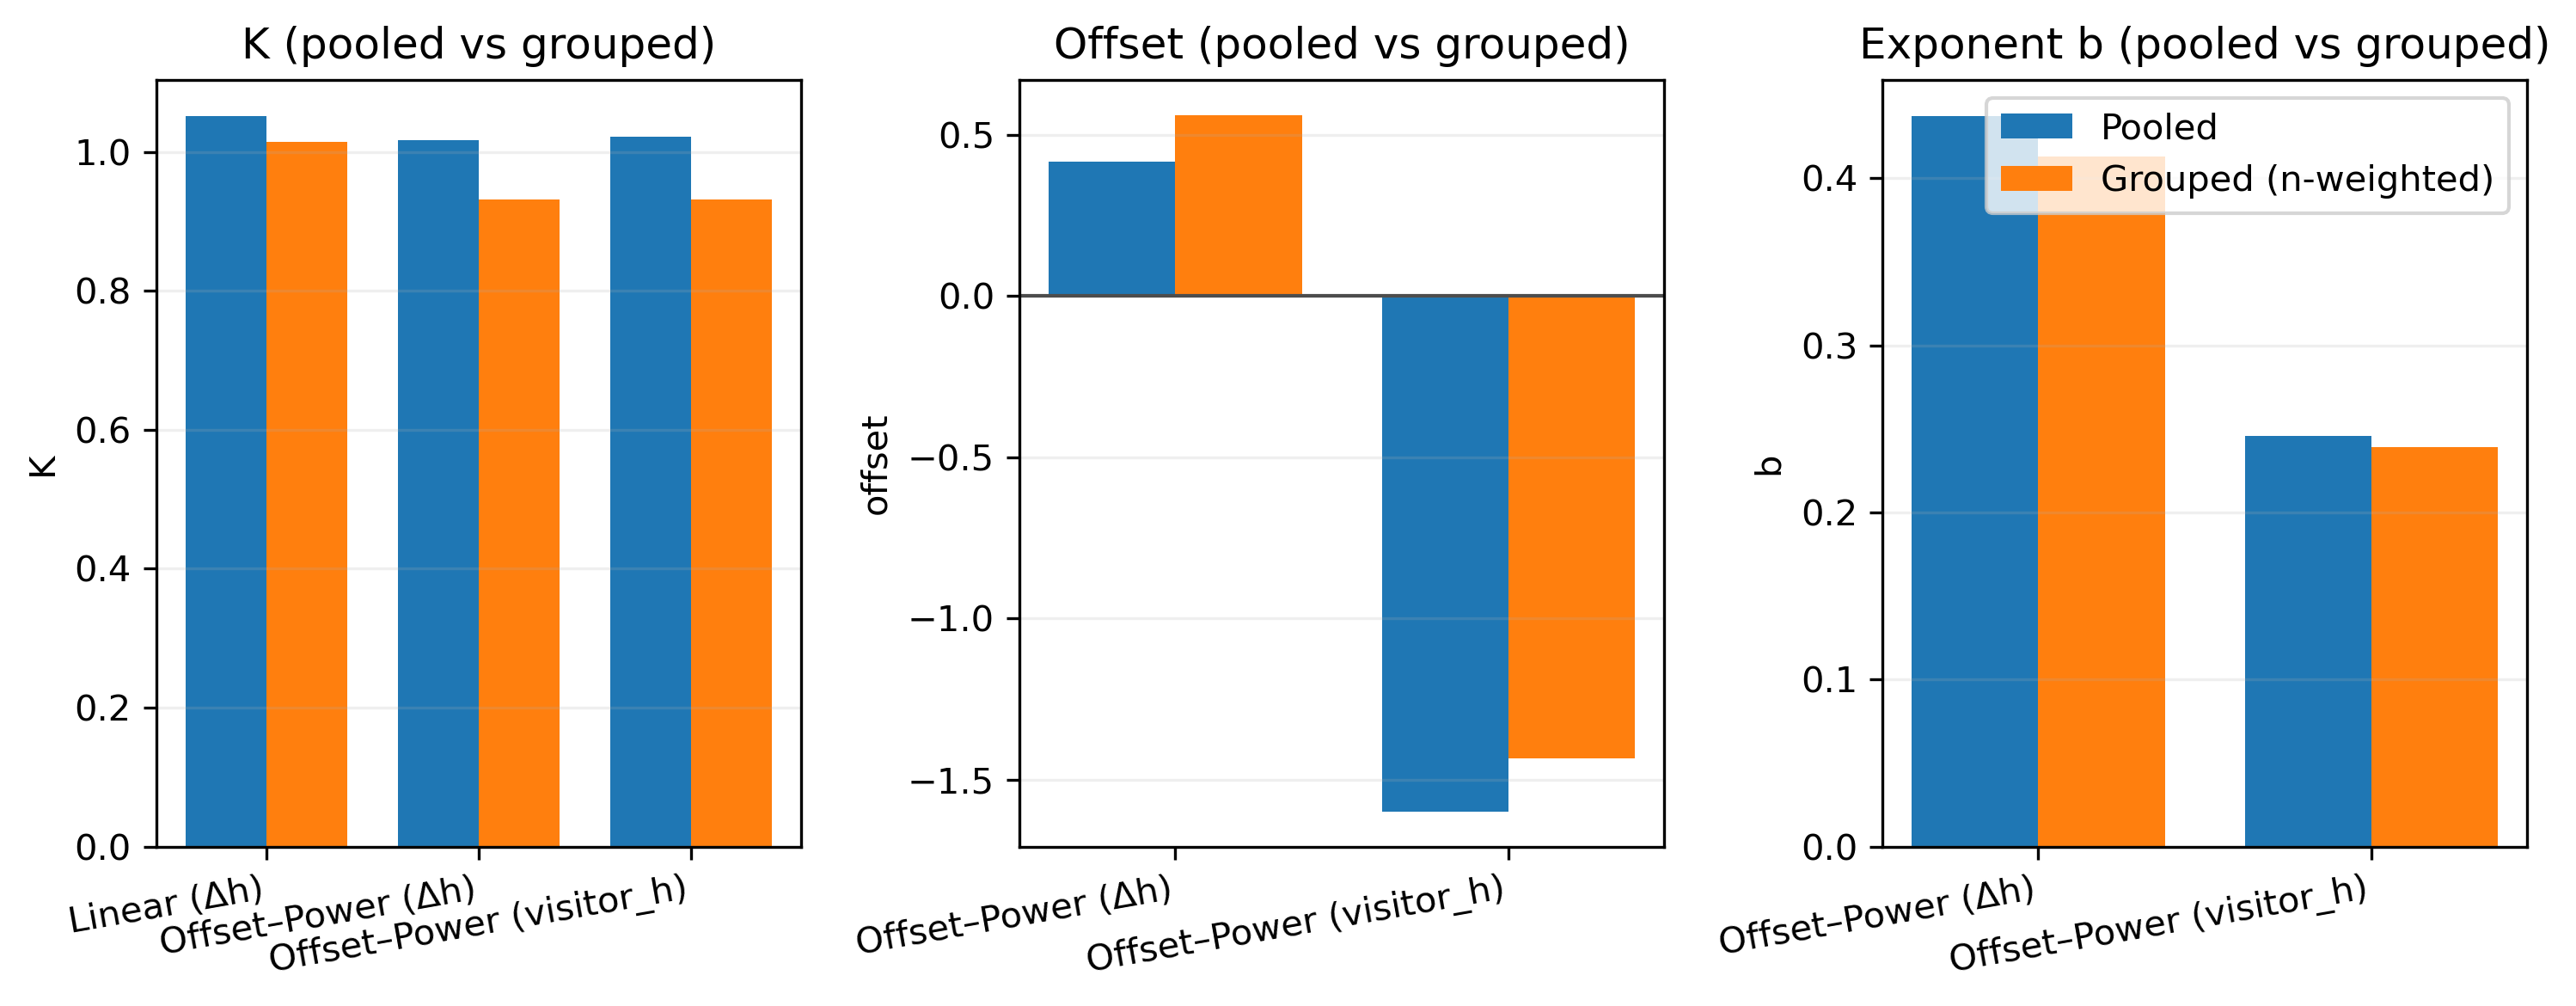

In [29]:
# --- comparison plots: pooled vs grouped (K, offset, b) ---

import numpy as np
import matplotlib.pyplot as plt

# ensure numeric dtype for plotting
for c in ["Pooled K","Grouped K","Pooled offset","Grouped offset","Pooled b","Grouped b"]:
    if c in comp.columns:
        comp[c] = pd.to_numeric(comp[c], errors="coerce")

fig, axes = plt.subplots(1, 3, figsize=(10, 4))                         
bar_w = 0.38

# 1) K comparison (all models)
ax = axes[0]
idx = np.arange(len(comp))
ax.bar(idx - bar_w/2, comp["Pooled K"],  bar_w, label="Pooled")
ax.bar(idx + bar_w/2, comp["Grouped K"], bar_w, label="Grouped (n-weighted)")
ax.set_xticks(idx)
ax.set_xticklabels(comp["Model"], rotation=10, ha="right")
ax.set_ylabel("K")
ax.set_title("K (pooled vs grouped)")
ax.grid(axis="y", alpha=0.2)


# 2) Offset comparison (power models only)
ax = axes[1]
m_off = comp["Pooled offset"].notna() | comp["Grouped offset"].notna()
comp_off = comp[m_off].reset_index(drop=True)
idx_off = np.arange(len(comp_off))
ax.bar(idx_off - bar_w/2, comp_off["Pooled offset"],  bar_w, label="Pooled")
ax.bar(idx_off + bar_w/2, comp_off["Grouped offset"], bar_w, label="Grouped (n-weighted)")
ax.axhline(0, color="0.3", lw=1)
ax.set_xticks(idx_off)
ax.set_xticklabels(comp_off["Model"], rotation=10, ha="right")
ax.set_ylabel("offset")
ax.set_title("Offset (pooled vs grouped)")
ax.grid(axis="y", alpha=0.2)

# 3) b comparison (power models only)
ax = axes[2]
m_b = comp["Pooled b"].notna() | comp["Grouped b"].notna()
comp_b = comp[m_b].reset_index(drop=True)
idx_b = np.arange(len(comp_b))
ax.bar(idx_b - bar_w/2, comp_b["Pooled b"],  bar_w, label="Pooled")
ax.bar(idx_b + bar_w/2, comp_b["Grouped b"], bar_w, label="Grouped (n-weighted)")
ax.set_xticks(idx_b)
ax.set_xticklabels(comp_b["Model"], rotation=10, ha="right")
ax.set_ylabel("b")
ax.set_title("Exponent b (pooled vs grouped)")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
ax.legend(frameon=True)

In [58]:
ev_vis['R2'].median(), ev_dh['R2'].median(), ev_lin['R2_lin'].median()

(0.7198858009780327, 0.7261762685821413, 0.5444217135974045)

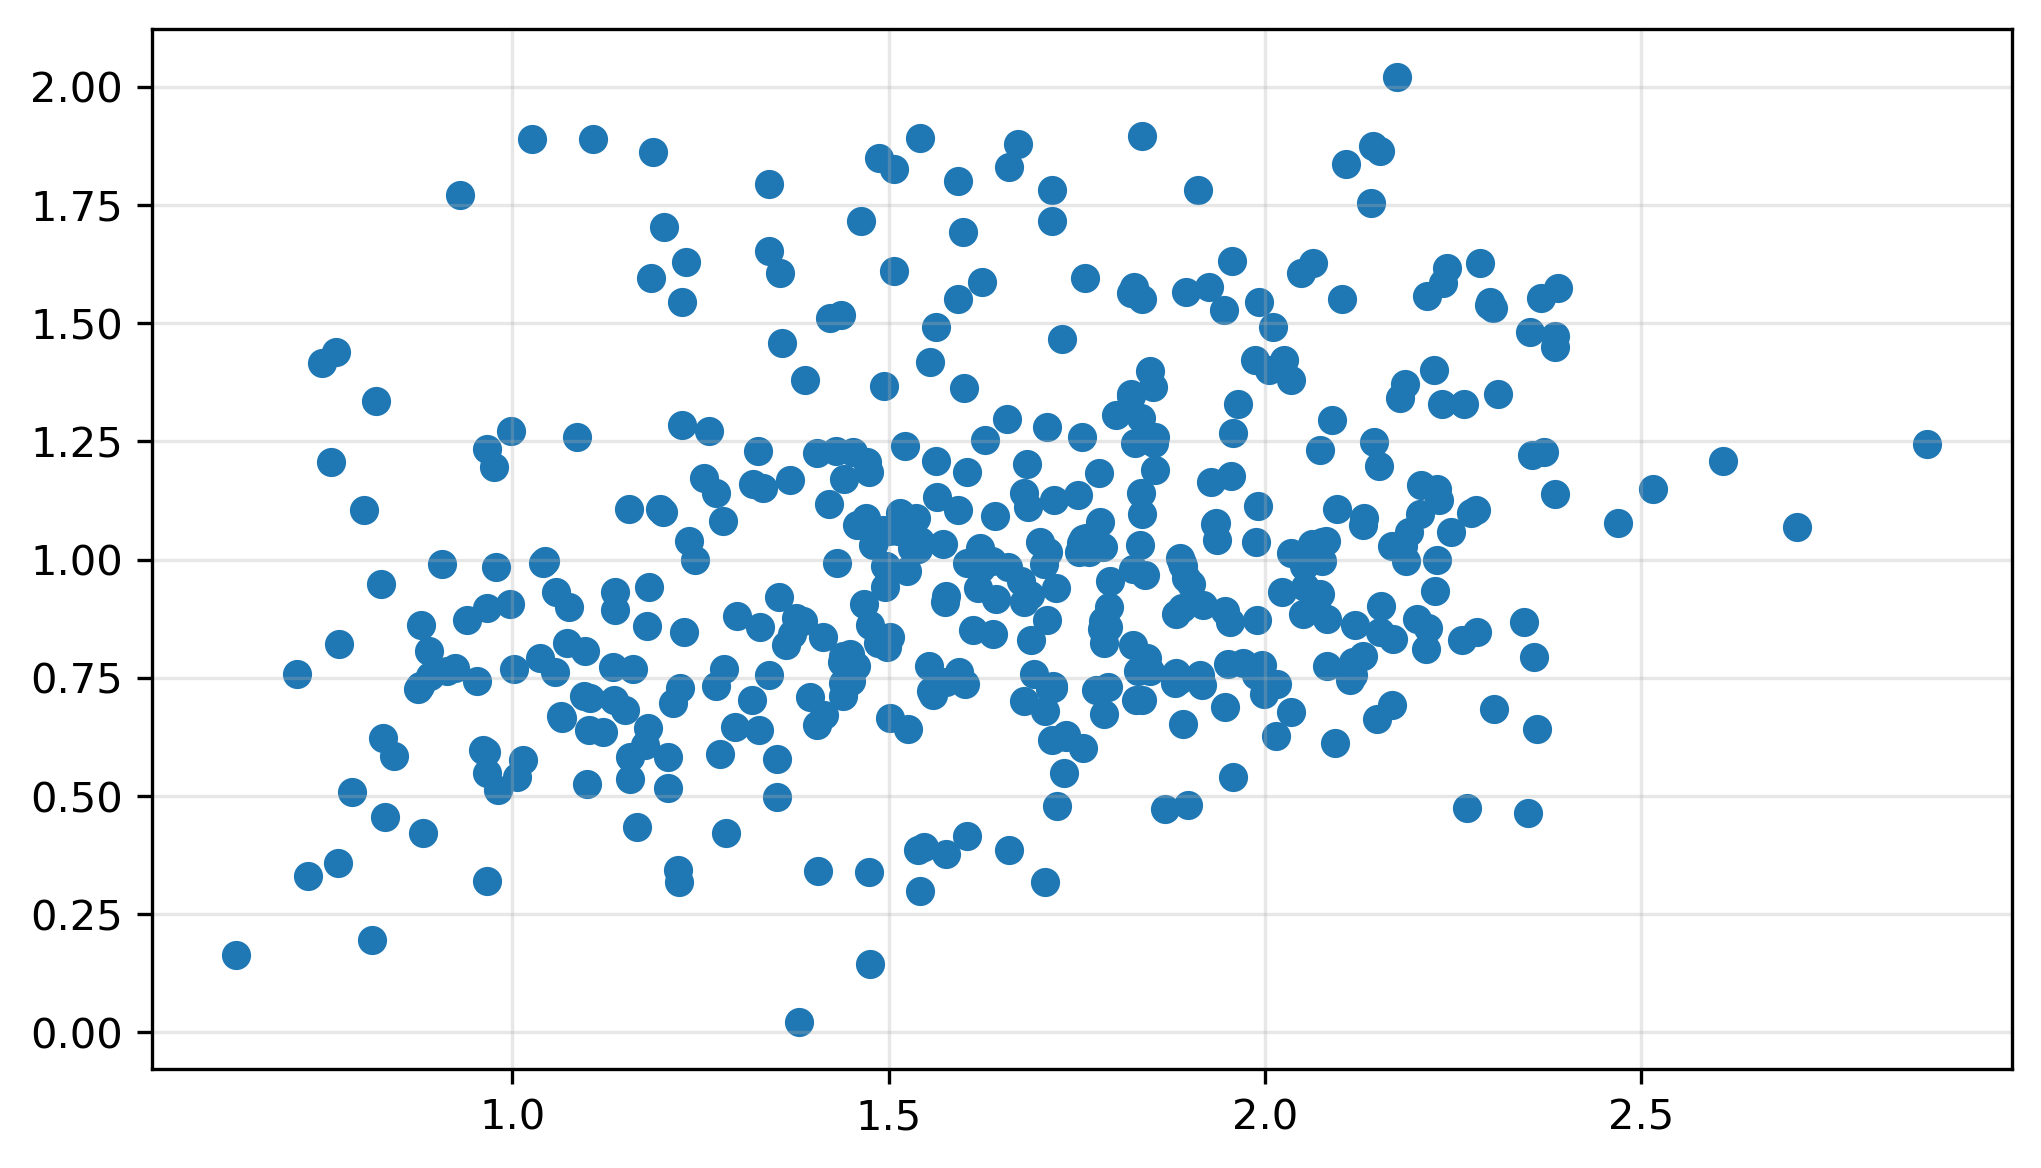

In [71]:
plt.scatter( df['delta_h'], (df['seepage']/df['delta_h']))

# plt.plot( df['visitor_h'], df['visitor_h']*0 + 0.546)

In [75]:

# --- Imports & configuration ---
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import minimize
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 300,
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# ---------------- Metrics ----------------
# def r2_centered(y: np.ndarray, yhat: np.ndarray) -> float:
#     """Centered R² = 1 − SSE/SST, where SST is around ȳ (fits are through origin)."""
#     sse = np.sum((y - yhat)**2)
#     sst = np.sum((y - y.mean())**2)
#     return 1 - sse/sst if sst > 0 else np.nan

def aic_gaussian(sse: float, n: int, k: int) -> float:
    """AIC for least squares under Gaussian errors: AIC = n·ln(SSE/n) + 2k (lower is better)."""
    return n * np.log(sse / n) + 2 * k

def bic_gaussian(sse: float, n: int, k: int) -> float:
    """BIC for least squares under Gaussian errors: BIC = n·ln(SSE/n) + k·ln(n) (lower is better)."""
    return n * np.log(sse / n) + k * np.log(n)

# # ------------- Helpers (inputs & scaling) -------------
# def _unpack_x(x):
#     """
#     Accept either:
#       - x: np.ndarray of Δh
#       - x: (delta_h, visitor_h) tuple
#     Returns (delta_h, visitor_h_or_None) as np.ndarrays.
#     """
#     if isinstance(x, (tuple, list)) and len(x) == 2:
#         dh, vh = x
#         return np.asarray(dh), np.asarray(vh)
#     return np.asarray(x), None

# def _median_scale(arr: np.ndarray) -> float:
#     """Robust, safe median used to non-dimensionalize powered terms."""
#     med = np.nanmedian(arr)
#     return float(med) if np.isfinite(med) and med != 0 else 1.0

# # ---------------- Models (through origin) ----------------
# # Physics framing: S = K * Δh * Φ^b, where Φ is a dimensionless driver of integrated conductance.

# def model_linear(params: np.ndarray, x) -> np.ndarray:
#     """Constant conductance: S = K · Δh."""
#     K = float(params[0])
#     dh, _ = _unpack_x(x)
#     return K * dh

# def model_dh_power(params: np.ndarray, x) -> np.ndarray:
#     """
#     Offset–power on head difference:
#         z_Δ = (Δh + offset_Δ) / m_Δ
#         S   = K · Δh · z_Δ^b_Δ
#     Enforces (Δh + offset_Δ) ≥ 0 implicitly via SSE guard.
#     """
#     K, offset, b = params
#     dh, _ = _unpack_x(x)
#     m_dh = _median_scale(dh)
                       
#     z_dh = (dh + offset) / m_dh
#     return K * dh * (z_dh ** b)

# def model_visitor_power(params: np.ndarray, x) -> np.ndarray:
#     """
#     Offset–power on estuary level (visitor gauge):
#         z_V = (h_visitor + offset_V) / m_V
#         S   = K · Δh · z_V^b_V
#     Requires x = (delta_h, visitor_h).
#     """
#     K, offset, b = params
#     dh, vh = _unpack_x(x)
#     if vh is None:
#         raise ValueError("model_visitor_power expects x=(delta_h, visitor_h).")
#     m_vh = _median_scale(vh)

#     z_vh = (vh + offset) / m_vh
#     return K * dh * (z_vh ** b)

# ---------------- Objectives (SSE) ----------------
def sse_linear(params: np.ndarray, x, y: np.ndarray) -> float:
    yhat = model_linear(params, x)
    return np.sum((y - yhat)**2)

def sse_dh_power(params: np.ndarray, x, y: np.ndarray) -> float:
    # Guard to keep powers real-valued
    dh, _ = _unpack_x(x)
    _, offset, _ = params
    if np.any((dh + offset) < 0):
        return np.inf
    yhat = model_dh_power(params, x)
    if not np.all(np.isfinite(yhat)):
        return np.inf
    return np.sum((y - yhat)**2)

def sse_visitor_power(params: np.ndarray, x, y: np.ndarray) -> float:
    # Guard to keep powers real-valued
    _, vh = _unpack_x(x)
    if vh is None:
        return np.inf
    _, offset, _ = params
    if np.any((vh + offset) < 0):
        return np.inf
    yhat = model_visitor_power(params, x)
    if not np.all(np.isfinite(yhat)):
        return np.inf
    return np.sum((y - yhat)**2)



## Load daily data
- Parse `delta_h` and `seepage` as numeric.
- Drop NA; enforce `delta_h > 0` (for power terms).


In [76]:
# from pathlib import Path
# import pandas as pd

# # Path to the pooled, event-labeled panel saved as CSV
# data_path = Path("../data/processed/pooled_event_df.csv")

# # Load the data
# pooled_event_df = pd.read_csv(data_path)

# # Ensure numeric types; coerce bad parses to NaN (so they can be dropped)
# pooled_event_df["delta_h"] = pd.to_numeric(pooled_event_df["delta_h"], errors="coerce")
# pooled_event_df["seepage"] = pd.to_numeric(pooled_event_df["seepage"], errors="coerce")

# # Drop rows missing either key variable
# pooled_event_df = pooled_event_df.dropna(subset=["delta_h", "seepage"])
# pooled_event_df["n"] = pooled_event_df.groupby("event")["event"].transform("size").astype("int64")


# # Quick peek at the core columns
# display(pooled_event_df[["delta_h", "seepage", "event"]].head())

# # Row count after cleaning (i.e., number of event-days retained)
# print(f"Closure days with data: {len(pooled_event_df)}")

# median_delta_h = pooled_event_df['delta_h'].median()
# min_delta_h = pooled_event_df['delta_h'].min()

In [77]:
# pooled_event_df = pooled_event_df.query("n > 6")

In [78]:
# pooled_event_df.shape


In [79]:
# pooled_event_df['delta_h'].min()


## Pooled fits (includes all events)

Optimize parameters by minimizing SSE with bounds:
- Offset–power: `K ≥ 0`
- Linear: `K ≥ 0`



In [80]:
# # --- helper to accept x as either array or (x, v) tuple ---
# def _unpack_x(x):
#     """
#     Accept either x as a 1-D array (Δh) or a tuple (Δh, v).
#     Returns (dh, v_or_None) as float arrays.
#     """
#     if isinstance(x, (tuple, list)):
#         dh = np.asarray(x[0], float)
#         v  = np.asarray(x[1], float) if len(x) > 1 else None
#     else:
#         dh = np.asarray(x, float)
#         v  = None
#     return dh, v

# # --- linear model now uses the helper safely ---
# def model_linear(params, x):
#     """Linear (Δh): S = K · Δh."""
#     K = float(params[0])
#     dh, _ = _unpack_x(x)
#     return K * dh

# # (optional) make sse_linear explicit, if not already
# def sse_linear(params, x, y):
#     yhat = model_linear(params, x)
#     return float(np.sum((y - yhat)**2))
 
    
# # pooled_event_df = df
# # # ============================
# # # Unified model fitting + bootstraps (DRY)
# # # ============================

# # import numpy as np
# # import pandas as pd
# # from scipy.optimize import minimize

# # # ---- Data prep --------------------------------------------------------------
# # x_all = pooled_event_df['delta_h'].to_numpy()
# # v_all = pooled_event_df['visitor_h'].to_numpy()   # estuary level
# # y_all = pooled_event_df['seepage'].to_numpy()

# # mask  = np.isfinite(x_all) & np.isfinite(v_all) & np.isfinite(y_all)
# # x_all, v_all, y_all = x_all[mask], v_all[mask], y_all[mask]
# # n_all = len(y_all)

# # # global positivity (keeps (Δh+offset) and (h_est+offset) > 0 on *all* rows)
# # eps       = 1e-9
# # lb_dh_all = -float(np.min(x_all)) + eps
# # lb_v_all  = -float(np.min(v_all)) + eps

# # # ---- Small helper: print interpretation legend -----------------------------
# # def _print_guidelines():
    
# #     print("• ΔRMSE: negative ⇒ first model has lower error; positive ⇒ second better.")
# #     print("• ΔAIC/ΔBIC: negative ⇒ first model preferred (penalizes complexity).")
# #     print("  Rules of thumb for |ΔAIC| or |ΔBIC|: ~2 weak, 4–7 moderate, ≥10 strong evidence.")
# #     print("• Paired bootstrap = fit & evaluate on same resampled rows (in-sample).")
# #     print("• OOB bootstrap = fit on in-bag; evaluate on out-of-bag rows (predictive).")

# # # ---- Core fitter ------------------------------------------------------------
# # def fit_all_models(x, v, y, *, lb_dh=lb_dh_all, lb_v=lb_v_all,
# #                    x0_lin=1.0, x0_dh=None, x0_v=None):
# #     """Fit linear, Δh-power, and z_v-power on the same sample; return metrics + pairwise contrasts."""
# #     n = len(y)

# #     # Linear
# #     res_l  = minimize(sse_linear, x0=[max(1e-3, x0_lin)], args=(x, y),
# #                       bounds=[(1e-12, None)], method="L-BFGS-B")
# #     K_l    = float(res_l.x[0])
# #     yhat_l = model_linear([K_l], x)
# #     sse_l  = sse_linear([K_l], x, y)
# #     rmse_l = np.sqrt(sse_l / n)
# #     r2_l   = r2_centered(y, yhat_l)
# #     aic_l  = aic_gaussian(sse_l, n, k=1)
# #     bic_l  = bic_gaussian(sse_l, n, k=1)

# #     # Δh-power
# #     if x0_dh is None:
# #         x0_dh = [max(1e-3, K_l), max(0.1, lb_dh + 0.01), 1.0]  # [K, offset, b]
# #     res_dh = minimize(sse_offset_power_delta_h, x0=x0_dh, args=(x, y),
# #                       bounds=[(1e-12, None), (lb_dh, None), (1e-12, None)],
# #                       method="L-BFGS-B")
# #     K_dh, off_dh, b_dh = map(float, res_dh.x)
# #     yhat_dh = sse_offset_power_delta_h(res_dh.x, x)
# #     sse_dh  = sse_offset_power_delta_h(res_dh.x, x, y)
# #     rmse_dh = np.sqrt(sse_dh / n)
# #     r2_dh   = r2_centered(y, yhat_dh)
# #     aic_dh  = aic_gaussian(sse_dh, n, k=3)
# #     bic_dh  = bic_gaussian(sse_dh, n, k=3)

# #     # z_v-power (estuary-power)
# #     if x0_v is None:
# #         x0_v = [max(1e-3, K_l), max(0.1, lb_v + 0.01), 1.0]
# #     res_v  = minimize(sse_visitor_power, x0=x0_v, args=((x, v), y),
# #                       bounds=[(1e-12, None), (lb_v, None), (1e-12, None)],
# #                       method="L-BFGS-B")
# #     K_v, off_v, b_v = map(float, res_v.x)
# #     yhat_v = model_visitor_power(res_v.x, (x, v))
# #     sse_v  = sse_visitor_power(res_v.x, (x, v), y)
# #     rmse_v = np.sqrt(sse_v / n)
# #     r2_v   = r2_centered(y, yhat_v)
# #     aic_v  = aic_gaussian(sse_v, n, k=3)
# #     bic_v  = bic_gaussian(sse_v, n, k=3)

# #     # Deltas vs linear
# #     dRMSE_dh, dSSE_dh, dR2_dh = rmse_dh - rmse_l, sse_dh - sse_l, r2_dh - r2_l
# #     dRMSE_v,  dSSE_v,  dR2_v  = rmse_v  - rmse_l, sse_v  - sse_l, r2_v  - r2_l
# #     dAIC_dh,  dBIC_dh        = aic_dh  - aic_l,   bic_dh - bic_l
# #     dAIC_v,   dBIC_v         = aic_v   - aic_l,   bic_v  - bic_l

# #     # z_v − Δh contrasts
# #     dRMSE_vd, dSSE_vd, dR2_vd = rmse_v - rmse_dh, sse_v - sse_dh, r2_v - r2_dh
# #     dAIC_vd,  dBIC_vd         = aic_v  - aic_dh,  bic_v - bic_dh

# #     return dict(
# #         # fitted params
# #         K_lin=K_l,
# #         K_dh=K_dh, offset_dh=off_dh, b_dh=b_dh,
# #         K_v =K_v,  offset_v =off_v,  b_v =b_v,
# #         # fit stats
# #         SSE_lin=sse_l, RMSE_lin=rmse_l, R2_lin=r2_l, AIC_lin=aic_l, BIC_lin=bic_l,
# #         SSE_dh=sse_dh, RMSE_dh=rmse_dh, R2_dh=r2_dh, AIC_dh=aic_dh, BIC_dh=bic_dh,
# #         SSE_v =sse_v,  RMSE_v =rmse_v,  R2_v =r2_v,  AIC_v =aic_v,  BIC_v =bic_v,
# #         # deltas vs linear
# #         dRMSE_dh=dRMSE_dh, dSSE_dh=dSSE_dh, dR2_dh=dR2_dh, dAIC_dh=dAIC_dh, dBIC_dh=dBIC_dh,
# #         dRMSE_v =dRMSE_v,  dSSE_v =dSSE_v,  dR2_v =dR2_v,  dAIC_v =dAIC_v,  dBIC_v =dBIC_v,
# #         # nonlinear pairwise
# #         dRMSE_v_minus_dh=dRMSE_vd, dSSE_v_minus_dh=dSSE_vd, dR2_v_minus_dh=dR2_vd,
# #         dAIC_v_minus_dh=dAIC_vd,   dBIC_v_minus_dh=dBIC_vd,
# #         # predictions (optional reuse)
# #         yhat_lin=yhat_l, yhat_dh=yhat_dh, yhat_v=yhat_v
# #     )

# # # ---- 1) Single-sample fits + summary ---------------------------------------
# # obs = fit_all_models(x_all, v_all, y_all)
# # summary = pd.DataFrame({
# #     "model": ["Linear: K*Δh", "Δh-power: K*Δh*z_Δ^b", "z_v-power: K*Δh*z_v^b"],
# #     "K": [obs["K_lin"], obs["K_dh"], obs["K_v"]],
# #     "offset": [np.nan, obs["offset_dh"], obs["offset_v"]],
# #     "b": [np.nan, obs["b_dh"], obs["b_v"]],
# #     "R2_centered": [obs["R2_lin"], obs["R2_dh"], obs["R2_v"]],
# #     "SSE": [obs["SSE_lin"], obs["SSE_dh"], obs["SSE_v"]],
# #     "AIC": [obs["AIC_lin"], obs["AIC_dh"], obs["AIC_v"]],
# #     "BIC": [obs["BIC_lin"], obs["BIC_dh"], obs["BIC_v"]],
# #     "n": [n_all, n_all, n_all],
# # })
# # display(summary.round(3))

# # print("Single-sample")
# # print(f"ΔAIC (Δh-power − linear)       = {obs['dAIC_dh']:.3f}")
# # print(f"ΔBIC (Δh-power − linear)       = {obs['dBIC_dh']:.3f}")
# # print(f"ΔAIC (z_v-power − linear)      = {obs['dAIC_v']:.3f}")
# # print(f"ΔBIC (z_v-power − linear)      = {obs['dBIC_v']:.3f}")
# # print(f"ΔAIC (z_v-power − Δh-power)    = {obs['dAIC_v_minus_dh']:.3f}")
# # print(f"ΔBIC (z_v-power − Δh-power)    = {obs['dBIC_v_minus_dh']:.3f}")

# # # # ---- 2) Paired bootstrap (in-sample) ---------------------------------------
# # rng = np.random.default_rng(42)
# # B = 100  # increase for tighter CIs

# # dRMSE_dh_bs = np.empty(B); dSSE_dh_bs = np.empty(B); dR2_dh_bs = np.empty(B); dAIC_dh_bs = np.empty(B); dBIC_dh_bs = np.empty(B)
# # dRMSE_v_bs  = np.empty(B); dSSE_v_bs  = np.empty(B); dR2_v_bs  = np.empty(B); dAIC_v_bs  = np.empty(B); dBIC_v_bs  = np.empty(B)
# # dRMSE_vd_bs = np.empty(B); dSSE_vd_bs = np.empty(B); dR2_vd_bs = np.empty(B); dAIC_vd_bs = np.empty(B); dBIC_vd_bs = np.empty(B)

# # x0_lin = obs['K_lin']
# # x0_dh  = [obs['K_dh'], obs['offset_dh'], max(0.0, obs['b_dh'])]
# # x0_v   = [obs['K_v'],  obs['offset_v'],  max(0.0, obs['b_v'])]

# # for b_iter in range(B):
# #     idx = rng.integers(0, n_all, n_all)
# #     xb, vb, yb = x_all[idx], v_all[idx], y_all[idx]
# #     res = fit_all_models(xb, vb, yb, lb_dh=lb_dh_all, lb_v=lb_v_all,
# #                          x0_lin=x0_lin, x0_dh=x0_dh, x0_v=x0_v)
# #     dRMSE_dh_bs[b_iter], dSSE_dh_bs[b_iter], dR2_dh_bs[b_iter] = res['dRMSE_dh'], res['dSSE_dh'], res['dR2_dh']
# #     dRMSE_v_bs[b_iter],  dSSE_v_bs[b_iter],  dR2_v_bs[b_iter]  = res['dRMSE_v'],  res['dSSE_v'],  res['dR2_v']
# #     dRMSE_vd_bs[b_iter], dSSE_vd_bs[b_iter], dR2_vd_bs[b_iter] = res['dRMSE_v_minus_dh'], res['dSSE_v_minus_dh'], res['dR2_v_minus_dh']
# #     dAIC_dh_bs[b_iter],  dBIC_dh_bs[b_iter] = res['dAIC_dh'], res['dBIC_dh']
# #     dAIC_v_bs[b_iter],   dBIC_v_bs[b_iter]  = res['dAIC_v'],  res['dBIC_v']
# #     dAIC_vd_bs[b_iter],  dBIC_vd_bs[b_iter] = res['dAIC_v_minus_dh'], res['dBIC_v_minus_dh']

# # pct = lambda a, q: np.nanpercentile(a, q)
# # ci = lambda arr: pct(arr, [2.5, 50, 97.5])

# # (ci_dRMSE_dh, ci_dSSE_dh, ci_dR2_dh, ci_dAIC_dh, ci_dBIC_dh) = map(ci, [dRMSE_dh_bs, dSSE_dh_bs, dR2_dh_bs, dAIC_dh_bs, dBIC_dh_bs])
# # (ci_dRMSE_v,  ci_dSSE_v,  ci_dR2_v,  ci_dAIC_v,  ci_dBIC_v)  = map(ci, [dRMSE_v_bs,  dSSE_v_bs,  dR2_v_bs,  dAIC_v_bs,  dBIC_v_bs])
# # (ci_dRMSE_vd, ci_dSSE_vd, ci_dR2_vd, ci_dAIC_vd, ci_dBIC_vd) = map(ci, [dRMSE_vd_bs, dSSE_vd_bs, dR2_vd_bs, dAIC_vd_bs, dBIC_vd_bs])

# # print("\nPaired bootstrap (in-sample) ")
# # print(f"ΔRMSE (Δh-power − linear):    median {ci_dRMSE_dh[1]:.4f}, 95% CI [{ci_dRMSE_dh[0]:.4f}, {ci_dRMSE_dh[2]:.4f}],  P(ΔRMSE<0)={np.mean(dRMSE_dh_bs<0):.3f}")
# # print(f"ΔRMSE (z_v-power − linear):   median {ci_dRMSE_v[1]:.4f},  95% CI [{ci_dRMSE_v[0]:.4f},  {ci_dRMSE_v[2]:.4f}],   P(ΔRMSE<0)={np.mean(dRMSE_v_bs<0):.3f}")
# # print(f"ΔRMSE (z_v-power − Δh-power): median {ci_dRMSE_vd[1]:.4f}, 95% CI [{ci_dRMSE_vd[0]:.4f}, {ci_dRMSE_vd[2]:.4f}],  P(ΔRMSE<0)={np.mean(dRMSE_vd_bs<0):.3f}")
# # print(f"ΔSSE  (z_v-power − Δh-power): median {ci_dSSE_vd[1]:.4f}, 95% CI [{ci_dSSE_vd[0]:.4f}, {ci_dSSE_vd[2]:.4f}]")
# # print(f"ΔR²   (z_v-power − Δh-power): median {ci_dR2_vd[1]:.4f}, 95% CI [{ci_dR2_vd[0]:.4f}, {ci_dR2_vd[2]:.4f}]")
# # print(f"ΔAIC  (z_v-power − Δh-power): median {ci_dAIC_vd[1]:.3f}, 95% CI [{ci_dAIC_vd[0]:.3f}, {ci_dAIC_vd[2]:.3f}]")
# # print(f"ΔBIC  (z_v-power − Δh-power): median {ci_dBIC_vd[1]:.3f}, 95% CI [{ci_dBIC_vd[0]:.3f}, {ci_dBIC_vd[2]:.3f}]")

# # # ---- 3) OOB bootstrap (predictive) -----------------------------------------
# # dRMSE_dh_oob, dRMSE_v_oob, dRMSE_vd_oob = [], [], []
# # rng = np.random.default_rng(43)

# # for _ in range(B):
# #     idx_inbag = rng.integers(0, n_all, n_all)
# #     inbag = np.zeros(n_all, dtype=bool); inbag[idx_inbag] = True
# #     oob = ~inbag
# #     if not np.any(oob):
# #         continue

# #     fit_ib = fit_all_models(x_all[inbag], v_all[inbag], y_all[inbag],
# #                             lb_dh=lb_dh_all, lb_v=lb_v_all,
# #                             x0_lin=x0_lin, x0_dh=x0_dh, x0_v=x0_v)

# #     # Predict OOB with in-bag params and in-bag medians (inside model fns)
# #     yhat_lin_oob = model_linear([fit_ib['K_lin']], x_all[oob])

# #     z_dh_oob = (x_all[oob] + fit_ib['offset_dh']) / _median_scale(x_all[inbag])
# #     yhat_dh_oob = fit_ib['K_dh'] * x_all[oob] * (z_dh_oob ** fit_ib['b_dh'])

# #     z_v_oob = (v_all[oob] + fit_ib['offset_v']) / _median_scale(v_all[inbag])
# #     yhat_v_oob = fit_ib['K_v'] * x_all[oob] * (z_v_oob ** fit_ib['b_v'])

# #     rmse_lin_oob = np.sqrt(np.mean((y_all[oob] - yhat_lin_oob)**2))
# #     rmse_dh_oob  = np.sqrt(np.mean((y_all[oob] - yhat_dh_oob )**2))
# #     rmse_v_oob   = np.sqrt(np.mean((y_all[oob] - yhat_v_oob  )**2))

# #     dRMSE_dh_oob.append(rmse_dh_oob - rmse_lin_oob)
# #     dRMSE_v_oob.append (rmse_v_oob  - rmse_lin_oob)
# #     dRMSE_vd_oob.append(rmse_v_oob  - rmse_dh_oob)

# # dRMSE_dh_oob = np.array(dRMSE_dh_oob); dRMSE_v_oob = np.array(dRMSE_v_oob); dRMSE_vd_oob = np.array(dRMSE_vd_oob)
# # ci_dh_oob = pct(dRMSE_dh_oob, [2.5, 50, 97.5]); ci_v_oob = pct(dRMSE_v_oob, [2.5, 50, 97.5]); ci_vd_oob = pct(dRMSE_vd_oob, [2.5, 50, 97.5])

# # []
# # print(f"\nOOB ΔRMSE (Δh-power − linear):    median {ci_dh_oob[1]:.4f}, 95% CI [{ci_dh_oob[0]:.4f}, \
# #       {ci_dh_oob[2]:.4f}], P(ΔRMSE<0)={np.mean(dRMSE_dh_oob<0):.3f}")
# # print(f"OOB ΔRMSE (z_v-power − linear):   median {ci_v_oob[1]:.4f},  95% CI [{ci_v_oob[0]:.4f},  \
# #       {ci_v_oob[2]:.4f}],  P(ΔRMSE<0)={np.mean(dRMSE_v_oob<0):.3f}")
# # print(f"OOB ΔRMSE (z_v-power − Δh-power): median {ci_vd_oob[1]:.4f}, 95% CI [{ci_vd_oob[0]:.4f}, \
# #       {ci_vd_oob[2]:.4f}], P(ΔRMSE<0)={np.mean(dRMSE_vd_oob<0):.3f}")

# # _print_guidelines()

# pooled_event_df = df
# # ============================
# # Unified model fitting + bootstraps (DRY)
# # ============================

# import numpy as np
# import pandas as pd
# from scipy.optimize import minimize

# # ---- Data prep --------------------------------------------------------------
# x_all = pooled_event_df['delta_h'].to_numpy()
# v_all = pooled_event_df['visitor_h'].to_numpy()   # estuary level
# y_all = pooled_event_df['seepage'].to_numpy()

# mask  = np.isfinite(x_all) & np.isfinite(v_all) & np.isfinite(y_all)
# x_all, v_all, y_all = x_all[mask], v_all[mask], y_all[mask]
# n_all = len(y_all)

# # global positivity (keeps (Δh+offset) and (h_est+offset) > 0 on *all* rows)
# eps        = 1e-9
# lb_dh_all  = -float(np.min(x_all)) + eps
# lb_v_all   = -float(np.min(v_all)) + eps

# # add gentle, global upper bounds for offsets (same units as x and v)
# q05_dh, q95_dh = np.quantile(x_all, [0.05, 0.95])
# spread_dh      = float(max(q95_dh - q05_dh, 1e-6))
# ub_dh_all      = min(0.30 * spread_dh, 3.0)  # bump cap if too tight for your site

# q05_v, q95_v = np.quantile(v_all, [0.05, 0.95])
# spread_v     = float(max(q95_v - q05_v, 1e-6))
# ub_v_all     = min(0.30 * spread_v, 3.0)

# # ensure feasible windows
# if ub_dh_all <= lb_dh_all + 1e-6:
#     ub_dh_all = lb_dh_all + max(0.05 * spread_dh, 0.05)
# if ub_v_all <= lb_v_all + 1e-6:
#     ub_v_all = lb_v_all + max(0.05 * spread_v, 0.05)

# # global normalizers (used by power models)
# x_ref_dh = float(np.median(x_all))   # normalizer for Δh-power
# v_ref    = float(np.median(v_all))   # normalizer for visitor/h_est power (if your visitor SSE uses it)

# # ---- Small helper: print interpretation legend -----------------------------
# def _print_guidelines():
#     print("• ΔRMSE: negative ⇒ first model has lower error; positive ⇒ second better.")
#     print("• ΔAIC/ΔBIC: negative ⇒ first model preferred (penalizes complexity).")
#     print("  Rules of thumb for |ΔAIC| or |ΔBIC|: ~2 weak, 4–7 moderate, ≥10 strong evidence.")
#     print("• Paired bootstrap = fit & evaluate on same resampled rows (in-sample).")
#     print("• OOB bootstrap = fit on in-bag; evaluate on out-of-bag rows (predictive).")

# # ---- Δh-power prediction model (used for yhat_dh) --------------------------
# def model_offset_power_delta_h(params, x, x_ref):
#     """
#     params = [K, offset, b]
#     yhat = K * x * ((x + offset)/x_ref)**b
#     """
#     K, off, b = map(float, params)
#     base = np.maximum(x + off, eps)
#     return K * x * np.power(base / max(x_ref, eps), b)

# # ---- Core fitter ------------------------------------------------------------
# def fit_all_models(x, v, y, *, lb_dh=lb_dh_all, lb_v=lb_v_all,
#                    x0_lin=1.0, x0_dh=None, x0_v=None):
#     """Fit linear, Δh-power, and z_v-power on the same sample; return metrics + pairwise contrasts."""
#     n = len(y)

#     # Linear
#     res_l  = minimize(sse_linear, x0=[max(1e-3, x0_lin)], args=(x, y),
#                       bounds=[(1e-12, None)], method="L-BFGS-B")
#     K_l    = float(res_l.x[0])
#     yhat_l = model_linear([K_l], x)
#     sse_l  = sse_linear([K_l], x, y)
#     rmse_l = np.sqrt(sse_l / n)
#     r2_l   = r2_centered(y, yhat_l)
#     aic_l  = aic_gaussian(sse_l, n, k=1)
#     bic_l  = bic_gaussian(sse_l, n, k=1)

#     # Δh-power  (pass required args: x_ref and both bounds; compute yhat with the model)
#     if x0_dh is None:
#         x0_dh = [max(1e-3, K_l), (lb_dh + ub_dh_all)/2.0, 1.0]  # [K, offset, b]
#     res_dh = minimize(
#         sse_offset_power_delta_h,
#         x0=x0_dh,
#         args=(x, y, x_ref_dh, lb_dh, ub_dh_all),
#         bounds=[(1e-12, None), (lb_dh, ub_dh_all), (1e-12, None)],
#         method="L-BFGS-B"
#     )
#     K_dh, off_dh, b_dh = map(float, res_dh.x)
#     yhat_dh = model_offset_power_delta_h(res_dh.x, x, x_ref_dh)
#     sse_dh  = sse_offset_power_delta_h(res_dh.x, x, y, x_ref_dh, lb_dh, ub_dh_all)
#     rmse_dh = np.sqrt(sse_dh / n)
#     r2_dh   = r2_centered(y, yhat_dh)
#     aic_dh  = aic_gaussian(sse_dh, n, k=3)
#     bic_dh  = bic_gaussian(sse_dh, n, k=3)

#     # z_v-power (estuary-power)
#     if x0_v is None:
#         x0_v = [max(1e-3, K_l), (lb_v + ub_v_all)/2.0, 1.0]
#     # If your sse_visitor_power expects (params, (x,v), y) ONLY, keep args as-is.
#     # If it also expects normalizer/bounds, extend args similarly to Δh-power.
#     res_v  = minimize(
#         sse_visitor_power,
#         x0=x0_v,
#         args=((x, v), y),  # extend if your signature needs v_ref, lb_v, ub_v_all
#         bounds=[(1e-12, None), (lb_v, ub_v_all), (1e-12, None)],
#         method="L-BFGS-B"
#     )
#     K_v, off_v, b_v = map(float, res_v.x)
#     yhat_v = model_visitor_power(res_v.x, (x, v))  # use your visitor model, not the SSE
#     sse_v  = sse_visitor_power(res_v.x, (x, v), y)
#     rmse_v = np.sqrt(sse_v / n)
#     r2_v   = r2_centered(y, yhat_v)
#     aic_v  = aic_gaussian(sse_v, n, k=3)
#     bic_v  = bic_gaussian(sse_v, n, k=3)

#     # Deltas vs linear
#     dRMSE_dh, dSSE_dh, dR2_dh = rmse_dh - rmse_l, sse_dh - sse_l, r2_dh - r2_l
#     dRMSE_v,  dSSE_v,  dR2_v  = rmse_v  - rmse_l, sse_v  - sse_l,  r2_v  - r2_l
#     dAIC_dh,  dBIC_dh        = aic_dh  - aic_l,   bic_dh - bic_l
#     dAIC_v,   dBIC_v         = aic_v   - aic_l,   bic_v  - bic_l

#     # z_v − Δh contrasts
#     dRMSE_vd, dSSE_vd, dR2_vd = rmse_v - rmse_dh, sse_v - sse_dh, r2_v - r2_dh
#     dAIC_vd,  dBIC_vd         = aic_v  - aic_dh,  bic_v - bic_dh

#     return dict(
#         # fitted params
#         K_lin=K_l,
#         K_dh=K_dh, offset_dh=off_dh, b_dh=b_dh,
#         K_v =K_v,  offset_v =off_v,  b_v =b_v,
#         # fit stats
#         SSE_lin=sse_l, RMSE_lin=rmse_l, R2_lin=r2_l, AIC_lin=aic_l, BIC_lin=bic_l,
#         SSE_dh=sse_dh, RMSE_dh=rmse_dh, R2_dh=r2_dh, AIC_dh=aic_dh, BIC_dh=bic_dh,
#         SSE_v =sse_v,  RMSE_v =rmse_v,  R2_v =r2_v,  AIC_v =aic_v,  BIC_v =bic_v,
#         # deltas vs linear
#         dRMSE_dh=dRMSE_dh, dSSE_dh=dSSE_dh, dR2_dh=dR2_dh, dAIC_dh=dAIC_dh, dBIC_dh=dBIC_dh,
#         dRMSE_v =dRMSE_v,  dSSE_v =dSSE_v,  dR2_v =dR2_v,  dAIC_v =dAIC_v,  dBIC_v =dBIC_v,
#         # nonlinear pairwise
#         dRMSE_v_minus_dh=dRMSE_vd, dSSE_v_minus_dh=dSSE_vd, dR2_v_minus_dh=dR2_vd,
#         dAIC_v_minus_dh=dAIC_vd,   dBIC_v_minus_dh=dBIC_vd,
#         # predictions (optional reuse)
#         yhat_lin=yhat_l, yhat_dh=yhat_dh, yhat_v=yhat_v
#     )

# # ---- 1) Single-sample fits + summary ---------------------------------------
# obs = fit_all_models(x_all, v_all, y_all)
# summary = pd.DataFrame({
#     "model": ["Linear: K*Δh", "Δh-power: K*Δh*z_Δ^b", "z_v-power: K*Δh*z_v^b"],
#     "K": [obs["K_lin"], obs["K_dh"], obs["K_v"]],
#     "offset": [np.nan, obs["offset_dh"], obs["offset_v"]],
#     "b": [np.nan, obs["b_dh"], obs["b_v"]],
#     "R2_centered": [obs["R2_lin"], obs["R2_dh"], obs["R2_v"]],
#     "SSE": [obs["SSE_lin"], obs["SSE_dh"], obs["SSE_v"]],
#     "AIC": [obs["AIC_lin"], obs["AIC_dh"], obs["AIC_v"]],
#     "BIC": [obs["BIC_lin"], obs["BIC_dh"], obs["BIC_v"]],
#     "n": [n_all, n_all, n_all],
# })
# display(summary.round(3))

# print("Single-sample")
# print(f"ΔAIC (Δh-power − linear)       = {obs['dAIC_dh']:.3f}")
# print(f"ΔBIC (Δh-power − linear)       = {obs['dBIC_dh']:.3f}")
# print(f"ΔAIC (z_v-power − linear)      = {obs['dAIC_v']:.3f}")
# print(f"ΔBIC (z_v-power − linear)      = {obs['dBIC_v']:.3f}")
# print(f"ΔAIC (z_v-power − Δh-power)    = {obs['dAIC_v_minus_dh']:.3f}")
# print(f"ΔBIC (z_v-power − Δh-power)    = {obs['dBIC_v_minus_dh']:.3f}")


TypeError: model_offset_power_delta_h() takes 3 positional arguments but 5 were given

In [61]:
pooled_event_df.delta_h.min()

0.6334449166666666

Δh - 0.53 >0
he - ho > 0.53 
he - 0.9 > 0.53 
he > 1.43

### 1. Interpreting AIC and BIC outputs 

---

* AIC (Akaike Information Criterion)
  $\text{AIC} = n \ln(\tfrac{\text{SSE}}{n}) + 2k$
  where $n$ is sample size, SSE the sum of squared residuals, and $k$ the number of free parameters.
  
     * Lower AIC means better expected **out-of-sample predictive accuracy** (minimizes KL divergence).
     * AIC penalizes complexity with $2k$.

* BIC (Bayesian Information Criterion)
  $\text{BIC} = n \ln(\tfrac{\text{SSE}}{n}) + k \ln n$
  
     *  Lower BIC means stronger evidence for the model under a Bayesian marginal likelihood approximation.
     *  BIC penalizes complexity more heavily than AIC (because $k \ln n \gg 2k$ when $n$ is large).

---

Assumptions: AIC and BIC both derive from the same likelihood framework:

* Residuals are independent, identically distributed, Gaussian with constant variance.
* Models are fit by maximum likelihood (least-squares regression used here satisfies this).
* AIC’s information-theoretic foundation is predictive (best for model comparison, not “truth”).
* BIC’s Bayesian foundation is evidence-based (tries to approximate posterior probability of models).
* Absolute AIC/BIC values are meaningless — only differences (ΔAIC, ΔBIC) matter.

---

How to interpret these numbers:


* If ΔAIC < 0: the offset–power model is preferred (strongly if Δ ≤ −10).
* If ΔAIC > 0: the linear model is preferred.
  
  Rules of thumb for ΔAIC:

  * 0–2: negligible support
  * 4–7: some support
  * ≥10: strong/decisive support

* If ΔBIC < 0: offset–power is preferred; ΔBIC > 0: linear is preferred.
  BIC is harsher on complexity, so if ΔAIC is slightly negative (favoring offset–power) but ΔBIC is positive (favoring linear), it means:


* If ΔAIC is small (say −2) and ΔBIC is positive, then the offset–power adds complexity without convincing gains → stick with linear.
* If ΔAIC is very negative (≤−10), then the extra parameters clearly buy predictive accuracy, even if BIC is still skeptical.


## Grouped fits (per event)
For each closure event, fit both models, compute $R^2$, SSE, AIC, BIC.  
Aggregate by:
- Weighted centered $R^2$ (weights = per-event samples `n`),
- Summed AIC/BIC across events.


In [ ]:
# ============================
# Per-event fits (linear, Δh-power, z_v-power) — deltas-only reporting
# Uses GLOBAL bounds for all events to keep (Δh+offset) and (h_est+offset) > 0
# Includes K, b, R2(linear), and dR2 columns in tables
# ============================

import numpy as np
import pandas as pd
from scipy.optimize import minimize

# ---- GLOBAL bounds computed once over all pooled rows -----------------------
eps        = 1e-9
X_ALL      = pooled_event_df['delta_h'].to_numpy()
V_ALL      = pooled_event_df['visitor_h'].to_numpy()
Y_ALL      = pooled_event_df['seepage'].to_numpy()
mask_all   = np.isfinite(X_ALL) & np.isfinite(V_ALL) & np.isfinite(Y_ALL)
X_ALL, V_ALL = X_ALL[mask_all], V_ALL[mask_all]
LB_DH_ALL  = -float(np.min(X_ALL)) + eps      # ensures (Δh + offset) > 0 on ALL rows
LB_V_ALL   = -float(np.min(V_ALL)) + eps      # ensures (h_est + offset) > 0 on ALL rows

print (LB_DH_ALL)
rows = []

for event, d in pooled_event_df.groupby('event'):
    # --- Extract arrays for this event --------------------------------------
    x = d['delta_h'].to_numpy()
    v = d['visitor_h'].to_numpy()   # estuary level
    y = d['seepage'].to_numpy()
    n = len(x)
    if n < 6:
        continue  # skip tiny samples—unstable fits

    # --- Linear (through origin): S = K * Δh --------------------------------
    rl = minimize(sse_linear, x0=[1.0], args=(x, y),
                  bounds=[(1e-12, None)], method="L-BFGS-B")
    K_lin   = float(rl.x[0])
    yhat_lin = model_linear([K_lin], x)
    SSE_lin  = sse_linear([K_lin], x, y)
    R2_lin   = r2_centered(y, yhat_lin)
    AIC_lin  = aic_gaussian(SSE_lin, n, k=1)
    BIC_lin  = bic_gaussian(SSE_lin, n, k=1)

    # --- Δh-power: S = K * Δh * z_Δ^b,  z_Δ=((Δh+offset)/median(Δh)) --------
    x0_dh = [max(1e-3, K_lin), max(0.1, LB_DH_ALL + 0.01), 1.0]  # [K, offset, b]
    rd = minimize(
        sse_dh_power, x0=x0_dh, args=(x, y),
        bounds=[(1e-12, None), (LB_DH_ALL, 1), (1e-12, None)],
        method="L-BFGS-B",
    )
    K_dh, off_dh, b_dh = map(float, rd.x)
    yhat_dh = model_dh_power(rd.x, x)
    SSE_dh  = sse_dh_power(rd.x, x, y)
    R2_dh   = r2_centered(y, yhat_dh)
    AIC_dh  = aic_gaussian(SSE_dh, n, k=3)
    BIC_dh  = bic_gaussian(SSE_dh, n, k=3)

    # --- z_v-power (estuary-power): S = K * Δh * z_v^b, z_v=((h_est+offset)/median(h_est))
    x0_v = [max(1e-3, K_lin), max(0.1, LB_V_ALL + 0.01), 1.0]
    rv = minimize(
        sse_visitor_power, x0=x0_v, args=((x, v), y),
        bounds=[(1e-12, None), (LB_V_ALL, 1), (1e-12, None)],
        method="L-BFGS-B",
    )
    K_v, off_v, b_v = map(float, rv.x)
    yhat_v = model_visitor_power(rv.x, (x, v))
    SSE_v  = sse_visitor_power(rv.x, (x, v), y)
    R2_v   = r2_centered(y, yhat_v)
    AIC_v  = aic_gaussian(SSE_v, n, k=3)
    BIC_v  = bic_gaussian(SSE_v, n, k=3)

    # --- Per-event deltas (A − B) -------------------------------------------
    # vs linear
    dAIC_dh_vs_lin = AIC_dh - AIC_lin
    dBIC_dh_vs_lin = BIC_dh - BIC_lin
    dAIC_v_vs_lin  = AIC_v  - AIC_lin
    dBIC_v_vs_lin  = BIC_v  - BIC_lin
    # nonlinear pairwise (z_v − Δh)
    dAIC_v_vs_dh   = AIC_v  - AIC_dh
    dBIC_v_vs_dh   = BIC_v  - BIC_dh

    # winners (labels only; raw IC not reported)
    aic_winner = min(
        [("linear", AIC_lin), ("Δh-power", AIC_dh), ("z_v-power", AIC_v)],
        key=lambda t: t[1]
    )[0]
    bic_winner = min(
        [("linear", BIC_lin), ("Δh-power", BIC_dh), ("z_v-power", BIC_v)],
        key=lambda t: t[1]
    )[0]

    # --- Collect row ---------------------------------------------------------
    rows.append({
        "event": event, "n": n,

        # parameters (reported)
        "K_lin": K_lin,
        "K_dh": K_dh, "b_dh": b_dh,
        "K_v":  K_v,  "b_v":  b_v,

        # R² (levels + deltas)
        "R2_lin": R2_lin, "R2_dh": R2_dh, "R2_v": R2_v,
        "dR2_dh_vs_lin": R2_dh - R2_lin,
        "dR2_v_vs_lin":  R2_v  - R2_lin,
        "dR2_v_vs_dh":   R2_v  - R2_dh,

        # AIC/BIC deltas only
        "dAIC_dh_vs_lin": dAIC_dh_vs_lin, "dBIC_dh_vs_lin": dBIC_dh_vs_lin,
        "dAIC_v_vs_lin":  dAIC_v_vs_lin,  "dBIC_v_vs_lin":  dBIC_v_vs_lin,
        "dAIC_v_vs_dh":   dAIC_v_vs_dh,   "dBIC_v_vs_dh":   dBIC_v_vs_dh,

        # quick labels
        "AIC_winner": aic_winner, "BIC_winner": bic_winner,
    })

grouped_fit = pd.DataFrame(rows).sort_values("event")

# ---- Preview main table: include K, b, R2_lin, dR2s, and deltas ------------
preview_cols = [
    "event","n",
    "K_lin","K_dh","b_dh","K_v","b_v",
    "R2_lin","dR2_dh_vs_lin","dR2_v_vs_lin",
    "dAIC_dh_vs_lin","dAIC_v_vs_lin","dAIC_v_vs_dh",
    "dBIC_dh_vs_lin","dBIC_v_vs_lin","dBIC_v_vs_dh",
    "AIC_winner","BIC_winner",
]
# display(grouped_fit[preview_cols].head(12).round(3))

# ---------- Aggregate across events (deltas only) ----------
dAIC_dh_grouped  = grouped_fit["dAIC_dh_vs_lin"].median()
dAIC_v_grouped   = grouped_fit["dAIC_v_vs_lin"].median()
dAIC_vd_grouped  = grouped_fit["dAIC_v_vs_dh"].median()

dBIC_dh_grouped  = grouped_fit["dBIC_dh_vs_lin"].median()
dBIC_v_grouped   = grouped_fit["dBIC_v_vs_lin"].median()
dBIC_vd_grouped  = grouped_fit["dBIC_v_vs_dh"].median()

# Preference counts (per-event winners by AIC/BIC)
aic_best = grouped_fit["AIC_winner"].value_counts()
bic_best = grouped_fit["BIC_winner"].value_counts()

print("\n[Legend] Δ = A − B. For AIC/BIC/SSE/RMSE: negative ⇒ A preferred. For R²: positive ⇒ A preferred.")
print("Rule-of-thumb strength for |ΔAIC| or |ΔBIC|: ~2 weak, 4–7 moderate, ≥10 strong.\n")

print("[Medians across events — differences only]  (lower is better for AIC/BIC deltas)")
print(f"  ΔAIC vs linear → Δh-power: {dAIC_dh_grouped:.2f},  z_v-power: {dAIC_v_grouped:.2f};  z_v − Δh: {dAIC_vd_grouped:.2f}")
print(f"  ΔBIC vs linear → Δh-power: {dBIC_dh_grouped:.2f},  z_v-power: {dBIC_v_grouped:.2f};  z_v − Δh: {dBIC_vd_grouped:.2f}")

print("\n[Per-event preference counts]")
print(f"  AIC best — linear: {aic_best.get('linear',0)}, Δh-power: {aic_best.get('Δh-power',0)}, z_v-power: {aic_best.get('z_v-power',0)}")
print(f"  BIC best — linear: {bic_best.get('linear',0)}, Δh-power: {bic_best.get('Δh-power',0)}, z_v-power: {bic_best.get('z_v-power',0)}")

# ---------- Decision views (include K, b, R2_lin, dR2s) ----------
top_by_AIC = grouped_fit.sort_values(["dAIC_v_vs_lin","dAIC_dh_vs_lin"]).head(10)
top_by_BIC = grouped_fit.sort_values(["dBIC_v_vs_lin","dBIC_dh_vs_lin"]).head(10)

view_cols = [
    "event","n","AIC_winner","BIC_winner",
    "K_lin","K_dh","b_dh","K_v","b_v",
    "R2_lin","dR2_dh_vs_lin","dR2_v_vs_lin",
    "dAIC_v_vs_lin","dAIC_dh_vs_lin","dAIC_v_vs_dh",
    "dBIC_v_vs_lin","dBIC_dh_vs_lin","dBIC_v_vs_dh",
]
print("\n[Top 10 events by strongest improvement vs linear (AIC)]")
display(top_by_AIC[view_cols].round(3))

print("\n[Top 10 events by strongest improvement vs linear (BIC)]")
display(top_by_BIC[view_cols].round(3))



### Best-fit exponent $b$ and offset (per-event)
Weighted by sample count per event, plus robust summaries.


In [ ]:
from scipy.stats import normaltest
import numpy as np
import pandas as pd

# --- helpers ---
def weighted_quantile(x: np.ndarray, w: np.ndarray, q: float) -> float:
    """Weighted quantile in [0,1]; ignores non-finite; allows zero/uneven weights."""
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    m = np.isfinite(x) & np.isfinite(w) & (w >= 0)
    if not np.any(m):
        return np.nan
    x, w = x[m], w[m]
    s = w.sum()
    if s <= 0:
        return np.nan
    o = np.argsort(x, kind="mergesort")
    x, w = x[o], w[o]
    cw = np.cumsum(w, dtype=float) / s
    return np.interp(q, cw, x)

def weighted_iqr(x: np.ndarray, w: np.ndarray) -> tuple[float, float]:
    """Weighted IQR (q25, q75)."""
    return weighted_quantile(x, w, 0.25), weighted_quantile(x, w, 0.75)

def iqr_unweighted(x: np.ndarray) -> tuple[float, float]:
    """Unweighted IQR (q25, q75) with NaN-safe quantiles."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    q25, q75 = np.quantile(x, [0.25, 0.75])
    return (float(q25), float(q75))

def normality_p_unweighted(x: np.ndarray) -> float:
    """D’Agostino–Pearson normality p-value (H0: normal)."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 8:
        return np.nan
    _, p = normaltest(x)
    return float(p)

def fmt_iqr(q25: float, q75: float) -> str:
    if not np.isfinite(q25) or not np.isfinite(q75):
        return "—"
    return f"{q25:.3g} – {q75:.3g}"

def summarize(vals: np.ndarray, wts: np.ndarray):
    """Weighted/unweighted medians & IQRs + unweighted normality p (note returned but not printed)."""
    med_w = weighted_quantile(vals, wts, 0.50)
    q25_w, q75_w = weighted_iqr(vals, wts)
    vals_f = vals[np.isfinite(vals)]
    med_u = float(np.median(vals_f)) if vals_f.size else np.nan
    q25_u, q75_u = iqr_unweighted(vals)
    p = normality_p_unweighted(vals)
    note = ("reject normality; prefer medians/IQR" if (np.isfinite(p) and p < 0.05)
            else "no evidence against normality")
    return med_w, fmt_iqr(q25_w, q75_w), med_u, fmt_iqr(q25_u, q75_u), p, note

# --- data (weights by event sample size) ---
w = grouped_fit["n"].to_numpy()

# Build the series dict using the new column names; guard if any are missing
def _col(name):
    return grouped_fit[name].to_numpy() if name in grouped_fit.columns else np.full(len(grouped_fit), np.nan)


series = {
    # Exponents & offsets
    "b (Δh-power)":              _col("b_dh"),
    "offset (Δh-power)":         _col("offset_dh"),
    "b (z_v-power)":             _col("b_v"),
    "offset (z_v-power)":        _col("offset_v"),

    # R² levels
    "R² (linear)":               _col("R2_lin"),
    "R² (Δh-power)":             _col("R2_dh"),
    "R² (z_v-power)":            _col("R2_v"),

    # R² deltas
    "ΔR² (Δh − linear)":         _col("dR2_dh_vs_lin"),
    "ΔR² (z_v − linear)":        _col("dR2_v_vs_lin"),
    "ΔR² (z_v − Δh)":            _col("dR2_v_vs_dh"),

    # AIC/BIC deltas (differences only)
    "ΔAIC (Δh − linear)":        _col("dAIC_dh_vs_lin"),
    "ΔAIC (z_v − linear)":       _col("dAIC_v_vs_lin"),
    "ΔAIC (z_v − Δh)":           _col("dAIC_v_vs_dh"),
    "ΔBIC (Δh − linear)":        _col("dBIC_dh_vs_lin"),
    "ΔBIC (z_v − linear)":       _col("dBIC_v_vs_lin"),
    "ΔBIC (z_v − Δh)":           _col("dBIC_v_vs_dh"),
}

# --- build summary table with consistent columns ---
rows = {}
for name, vals in series.items():
    med_w, iqr_w, med_u, iqr_u, p, note = summarize(vals, w)
    rows[name] = {
        "median (unweighted)":      np.round(med_u, 3),
        "IQR q25–q75 (unweighted)": iqr_u,
        "median (weighted)":        np.round(med_w, 3),
        "IQR q25–q75 (weighted)":   iqr_w,
        # "normality p (unweighted)":  np.round(p, 3),  # uncomment if you want to display p
        # "note":                      note,            # uncomment to show the normality note
    }

summary_consistent = pd.DataFrame.from_dict(rows, orient="index")
display(summary_consistent.T.round(4).T)



## visualization: pooled data with fitted curves


In [ ]:

fig, ax = plt.subplots()
ax.scatter(x_all, y_all, s=10, c="0.5", alpha=0.7, label="")

order = np.argsort(x_all)
xs = x_all[order]
ax.plot(xs, model_linear([K_lin], xs), label=fr"$\hat S = {K_lin:.2f}\,\Delta h$")
ax.plot(xs, model_dh_power([K_dh, off_dh, b_dh], xs),
        label=fr"$\hat S = {K_dh:.2f}\,\Delta h(\Delta h {off_dh:.2f})^{{{b_dh:.2f}}}$")

ax.set_xlabel(r"$\Delta h$")
ax.set_ylabel(r"$S$")
ax.legend(frameon=False)
plt.show()
K_lin

In [72]:
# Minimal, decision-oriented columns
col_subset = [
    "event", "n",
    "K_lin", "K_pow", "offset", "b",      # parameters
    "R2_lin", "R2_pow", "dR2",            # fit quality
     "dAIC",                              # information criteria
     "dBIC",
]

# Show events with strongest improvement first (ΔAIC most negative)
grouped_table = (grouped_fit[col_subset]
              .sort_values("dR2")
              .reset_index(drop=True))

display(grouped_table.round(3))   # Top

grouped_table.median(axis = 0)

NameError: name 'grouped_fit' is not defined